In [ ]:
import os
import re
import numpy as np
import torch
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"
# Define folder names and their numeric labels
CATEGORIES = {
    'AD_graphs': 2,
    'CN_graphs': 0,
    'MCI_graphs': 1,
    'EMCI_graphs': 1,  # Merging into MCI class
    'LMCI_graphs': 1   # Merging into MCI class
}

def load_and_match_data(base_path, categories):
    all_data = []
    all_labels = []

    # Pattern to extract ADNI subject ID like 002S0413
    id_pattern = re.compile(r'\d{3}S\d{4}')

    for cat_folder, label in categories.items():
        p_path = f"{base_path}/{cat_folder}/Graph_Output"
        c_path = f"{base_path}/{cat_folder}/Graph_Output_Coherence"
        g_path = f"{base_path}/{cat_folder}/Graph_Output_Granger"

        if not os.path.exists(p_path): continue

        # Map IDs to specific filenames in each folder
        p_files = {id_pattern.search(f).group(): f for f in os.listdir(p_path) if id_pattern.search(f)}
        c_files = {id_pattern.search(f).group(): f for f in os.listdir(c_path) if id_pattern.search(f)}
        g_files = {id_pattern.search(f).group(): f for f in os.listdir(g_path) if id_pattern.search(f)}

        # Intersection: only subjects with ALL THREE graphs
        common_ids = set(p_files.keys()) & set(c_files.keys()) & set(g_files.keys())
        print(f"Category {cat_folder}: Found {len(common_ids)} complete subjects.")

        for sid in sorted(common_ids):
            p = np.load(os.path.join(p_path, p_files[sid]))
            c = np.load(os.path.join(c_path, c_files[sid]))
            g = np.load(os.path.join(g_path, g_files[sid]))

            # Stack into (Channels=3, N, N)
            combined = np.stack([p, c, g], axis=0)
            all_data.append(combined)
            all_labels.append(label)

    return np.array(all_data), np.array(all_labels)

# 1. Load Data
X, y = load_and_match_data(BASE_PATH, CATEGORIES)

# 2. Rescale/Normalize (Very important for high accuracy)
# We flatten to (Samples, Features) for SMOTE and scaling
N = X.shape[2]
X_flat = X.reshape(len(X), -1)
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_flat)

# 3. SMOTE for Class Balance (Synthetic AD samples)
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)

# 4. Reshape back for CNN (Samples, Channels, N, N)
X_final = X_resampled.reshape(-1, 3, N, N)
print(f"Final Dataset Shape: {X_final.shape} (Balanced)")

Category AD_graphs: Found 26 complete subjects.
Category CN_graphs: Found 59 complete subjects.
Category MCI_graphs: Found 31 complete subjects.
Category EMCI_graphs: Found 28 complete subjects.
Category LMCI_graphs: Found 28 complete subjects.
Final Dataset Shape: (261, 3, 116, 116) (Balanced)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class NeuroVistaNet(nn.Module):
    def __init__(self):
        super(NeuroVistaNet, self).__init__()
        # Input: (3, 116, 116)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Pooling to reduce dimensions
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        # After two pools, 116 -> 58 -> 29
        self.fc1 = nn.Linear(64 * 29 * 29, 128)
        self.dropout = nn.Dropout(0.5) # Prevents overfitting
        self.fc2 = nn.Linear(128, 3) # 3 classes: CN, MCI, AD

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [ ]:
# Convert your prepared X_final and y_resampled to Tensors
X_tensor = torch.from_numpy(X_final).float()
y_tensor = torch.from_numpy(y_resampled).long()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fold_results = []

print(f"Starting training on {device}...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y_resampled)):
    # Create DataLoaders
    train_ds = TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
    val_ds = TensorDataset(X_tensor[val_idx], y_tensor[val_idx])
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=16)

    # Initialize model, optimizer, and loss
    model = NeuroVistaNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    # Train for 50 epochs
    for epoch in range(50):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # Evaluation for this fold
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

    acc = 100 * correct / total
    fold_results.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc:.2f}%")

print(f"\n--- Final Results ---")
print(f"Mean Accuracy: {np.mean(fold_results):.2f}%")
print(f"Standard Deviation: {np.std(fold_results):.2f}%")

Starting training on cuda...
Fold 1 Accuracy: 83.02%
Fold 2 Accuracy: 71.15%
Fold 3 Accuracy: 75.00%
Fold 4 Accuracy: 65.38%
Fold 5 Accuracy: 75.00%

--- Final Results ---
Mean Accuracy: 73.91%
Standard Deviation: 5.76%


In [ ]:
import torch.optim as optim

def train_refined_model():
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    final_fold_accs = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y_resampled)):
        train_loader = DataLoader(TensorDataset(X_tensor[train_idx], y_tensor[train_idx]), batch_size=16, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_tensor[val_idx], y_tensor[val_idx]), batch_size=16)

        model = NeuroVistaNet().to(device)

        # Optimization Tweaks
        optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3) # Higher weight decay to reduce variance
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
        criterion = nn.CrossEntropyLoss()

        best_acc = 0
        for epoch in range(60): # Slightly more epochs
            model.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(batch_x), batch_y)
                loss.backward()
                optimizer.step()

            # Mid-training Evaluation
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for bx, by in val_loader:
                    bx, by = bx.to(device), by.to(device)
                    preds = model(bx).argmax(dim=1)
                    correct += (preds == by).sum().item()
                    total += by.size(0)

            current_acc = 100 * correct / total
            scheduler.step(current_acc) # Adjust LR based on performance

            if current_acc > best_acc:
                best_acc = current_acc

        final_fold_accs.append(best_acc)
        print(f"Fold {fold+1} Best Accuracy: {best_acc:.2f}%")

    print(f"\n--- Improved Results ---")
    print(f"New Mean Accuracy: {np.mean(final_fold_accs):.2f}%")
    print(f"New Std Deviation: {np.std(final_fold_accs):.2f}%")

train_refined_model()

Fold 1 Best Accuracy: 81.13%
Fold 2 Best Accuracy: 76.92%
Fold 3 Best Accuracy: 67.31%
Fold 4 Best Accuracy: 67.31%
Fold 5 Best Accuracy: 67.31%

--- Improved Results ---
New Mean Accuracy: 72.00%
New Std Deviation: 5.89%


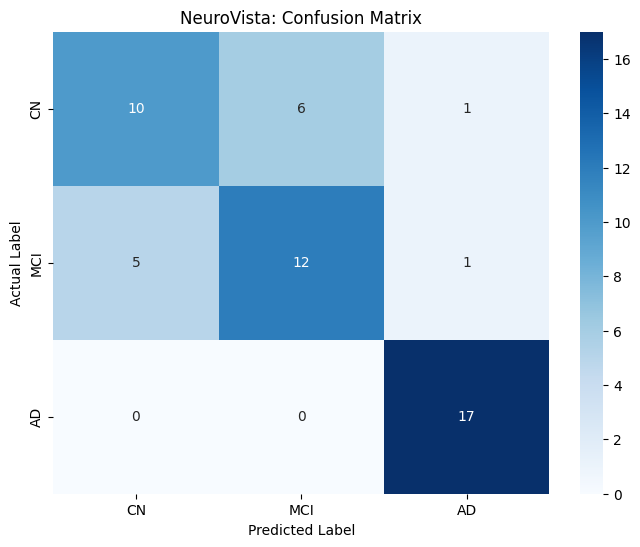


--- Detailed Classification Report ---
              precision    recall  f1-score   support

          CN       0.67      0.59      0.62        17
         MCI       0.67      0.67      0.67        18
          AD       0.89      1.00      0.94        17

    accuracy                           0.75        52
   macro avg       0.74      0.75      0.75        52
weighted avg       0.74      0.75      0.74        52



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_neurovista_results(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    # 1. Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # 2. Plotting the Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['CN', 'MCI', 'AD'],
                yticklabels=['CN', 'MCI', 'AD'])

    plt.title('NeuroVista: Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # 3. Print the classification report (Precision, Recall, F1)
    print("\n--- Detailed Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=['CN', 'MCI', 'AD']))

# Call the function (assuming 'model', 'val_loader', and 'device' are defined from your loop)
plot_neurovista_results(model, val_loader, device)

**TRY 2**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NeuroVistaNet_v2(nn.Module):
    def __init__(self):
        super(NeuroVistaNet_v2, self).__init__()
        # Input (3, 116, 116)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # Extra intelligence layer
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        # After 3 pools of size 2: 116 -> 58 -> 29 -> 14
        self.fc1 = nn.Linear(128 * 14 * 14, 256)
        self.dropout = nn.Dropout(0.6) # Stronger dropout to prevent overfitting
        self.fc2 = nn.Linear(256, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, TensorDataset

# Prepare class weights [CN, MCI, AD]
# Higher weight for AD (Class 2) to force the model to prioritize it
class_weights = torch.tensor([1.0, 1.0, 2.5]).cuda()

def train_best_model():
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    device = torch.device("cuda")
    fold_accs = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y_resampled)):
        train_loader = DataLoader(TensorDataset(X_tensor[train_idx], y_tensor[train_idx]), batch_size=16, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_tensor[val_idx], y_tensor[val_idx]), batch_size=16)

        model = NeuroVistaNet_v2().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-3)
        criterion = nn.CrossEntropyLoss(weight=class_weights) # ADDED WEIGHTS HERE

        best_fold_acc = 0
        for epoch in range(60):
            model.train()
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

            # Eval best performance for this fold
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for bx, by in val_loader:
                    bx, by = bx.to(device), by.to(device)
                    preds = model(bx).argmax(dim=1)
                    correct += (preds == by).sum().item()
                    total += by.size(0)

            acc = 100 * correct / total
            if acc > best_fold_acc:
                best_fold_acc = acc

        fold_accs.append(best_fold_acc)
        print(f"Fold {fold+1} Optimized Acc: {best_fold_acc:.2f}%")

    print(f"\n--- Final Optimized Results ---")
    print(f"Mean Accuracy: {np.mean(fold_accs):.2f}%")
    return model, val_loader # Return last fold for confusion matrix

# Execute
final_model, last_val_loader = train_best_model()

Fold 1 Optimized Acc: 84.91%
Fold 2 Optimized Acc: 78.85%
Fold 3 Optimized Acc: 80.77%
Fold 4 Optimized Acc: 76.92%
Fold 5 Optimized Acc: 86.54%

--- Final Optimized Results ---
Mean Accuracy: 81.60%


# SINGLE CM

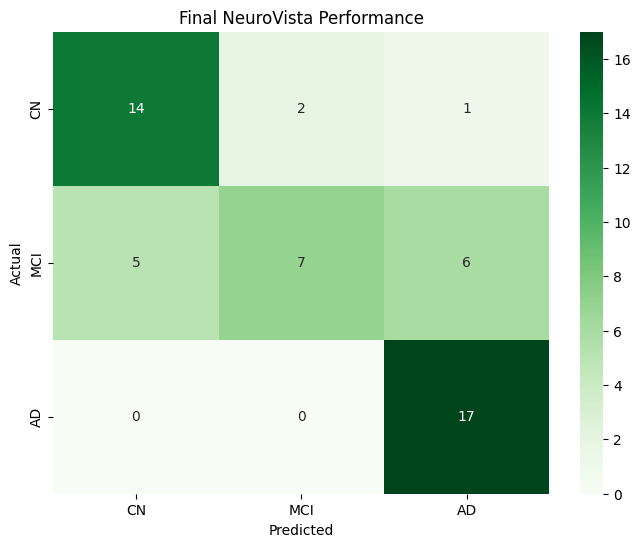

              precision    recall  f1-score   support

          CN       0.74      0.82      0.78        17
         MCI       0.78      0.39      0.52        18
          AD       0.71      1.00      0.83        17

    accuracy                           0.73        52
   macro avg       0.74      0.74      0.71        52
weighted avg       0.74      0.73      0.70        52



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def plot_final_matrix(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for bx, by in loader:
            outputs = model(bx.cuda())
            y_pred.extend(outputs.argmax(dim=1).cpu().numpy())
            y_true.extend(by.numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['CN', 'MCI', 'AD'], yticklabels=['CN', 'MCI', 'AD'])
    plt.title('Final NeuroVista Performance')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print(classification_report(y_true, y_pred, target_names=['CN', 'MCI', 'AD']))

plot_final_matrix(final_model, last_val_loader)

# Combined Confusion Matrix:

Fold 1 processed.
Fold 2 processed.
Fold 3 processed.
Fold 4 processed.
Fold 5 processed.


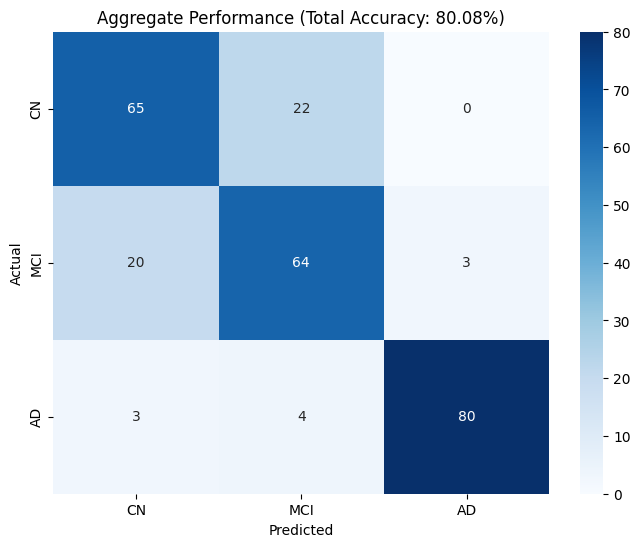

              precision    recall  f1-score   support

          CN       0.74      0.75      0.74        87
         MCI       0.71      0.74      0.72        87
          AD       0.96      0.92      0.94        87

    accuracy                           0.80       261
   macro avg       0.80      0.80      0.80       261
weighted avg       0.80      0.80      0.80       261



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def train_and_get_all_preds():
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    device = torch.device("cuda")

    all_y_true = []
    all_y_pred = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y_resampled)):
        train_loader = DataLoader(TensorDataset(X_tensor[train_idx], y_tensor[train_idx]), batch_size=16, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_tensor[val_idx], y_tensor[val_idx]), batch_size=16)

        model = NeuroVistaNet_v2().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-3)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        # Training
        best_val_preds = []
        best_val_labels = []
        max_acc = 0

        for epoch in range(60):
            model.train()
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

            # Track predictions for the BEST epoch of this fold
            model.eval()
            temp_preds, temp_labels = [], []
            with torch.no_grad():
                for bx, by in val_loader:
                    bx, by = bx.to(device), by.to(device)
                    outputs = model(bx)
                    temp_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                    temp_labels.extend(by.cpu().numpy())

            acc = (np.array(temp_preds) == np.array(temp_labels)).mean()
            if acc > max_acc:
                max_acc = acc
                best_val_preds = temp_preds
                best_val_labels = temp_labels

        all_y_pred.extend(best_val_preds)
        all_y_true.extend(best_val_labels)
        print(f"Fold {fold+1} processed.")

    # Plot Aggregate Matrix
    cm = confusion_matrix(all_y_true, all_y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['CN', 'MCI', 'AD'], yticklabels=['CN', 'MCI', 'AD'])
    plt.title(f'Aggregate Performance (Total Accuracy: {np.mean(np.array(all_y_true) == np.array(all_y_pred))*100:.2f}%)')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    print(classification_report(all_y_true, all_y_pred, target_names=['CN', 'MCI', 'AD']))

train_and_get_all_preds()

In [ ]:
# Calculate counts
classes, counts = np.unique(y_resampled, return_counts=True)

# Map numeric labels back to names for clarity
class_names = {0: 'CN', 1: 'MCI', 2: 'AD'}

print("--- Subject Counts After SMOTE ---")
for c, count in zip(classes, counts):
    print(f"Class {class_names[c]} ({c}): {count} subjects")

print(f"\nTotal Dataset Size: {sum(counts)}")

--- Subject Counts After SMOTE ---
Class CN (0): 87 subjects
Class MCI (1): 87 subjects
Class AD (2): 87 subjects

Total Dataset Size: 261


In [ ]:
# Save the model weights
model_save_path = "/content/drive/MyDrive/NEUROVISTA-PROJECT/OUR-MODELS/3CLASS-MODEL/3CLASS_81.6_model.pth"
torch.save(final_model.state_dict(), model_save_path)
print(f"Model successfully saved to {model_save_path}")

Model successfully saved to /content/drive/MyDrive/NEUROVISTA-PROJECT/OUR-MODELS/3CLASS-MODEL/3CLASS_81.6_model.pth


# ACTUAL- CODE FOR 81.6% ACCURACY

In [ ]:
# import os
# file_path = "/content/drive/MyDrive/NEUROVISTA-PROJECT/OUR-MODELS/3CLASS-MODEL/3CLASS_81.6_model.pth"
# file_size = os.path.getsize(file_path) / (1024 * 1024) # Convert to MB
# print(f"Model saved at: {file_path}")
# print(f"Model File Size: {file_size:.2f} MB")

Model saved at: /content/drive/MyDrive/NEUROVISTA-PROJECT/OUR-MODELS/3CLASS-MODEL/3CLASS_81.6_model.pth
Model File Size: 24.87 MB


## VERSION3

In [ ]:
#Cell 1: Setup & Libraries
import os
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from torch.utils.data import DataLoader, TensorDataset
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix


# Configuration
BASE_PATH = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"
CATEGORIES = {'AD_graphs': 2, 'CN_graphs': 0, 'MCI_graphs': 1, 'EMCI_graphs': 1, 'LMCI_graphs': 1}

In [ ]:
#Cell 2: Data Loader
def load_and_match_data(base_path, categories):
    all_data, all_labels = [], []
    id_pattern = re.compile(r'\d{3}S\d{4}')

    for cat_folder, label in categories.items():
        paths = [f"{base_path}/{cat_folder}/Graph_Output",
                 f"{base_path}/{cat_folder}/Graph_Output_Coherence",
                 f"{base_path}/{cat_folder}/Graph_Output_Granger"]

        if not os.path.exists(paths[0]): continue

        files = [{id_pattern.search(f).group(): f for f in os.listdir(p) if id_pattern.search(f)} for p in paths]
        common_ids = set(files[0].keys()) & set(files[1].keys()) & set(files[2].keys())
        print(f"Loading {cat_folder}: {len(common_ids)} subjects")

        for sid in sorted(common_ids):
            ch = [np.load(os.path.join(paths[i], files[i][sid])) for i in range(3)]
            all_data.append(np.stack(ch, axis=0))
            all_labels.append(label)

    return np.array(all_data), np.array(all_labels)

X, y = load_and_match_data(BASE_PATH, CATEGORIES)
X_scaled = MinMaxScaler().fit_transform(X.reshape(len(X), -1))
print(f"Dataset Ready: {X.shape[0]} subjects.")

Loading AD_graphs: 26 subjects
Loading CN_graphs: 59 subjects
Loading MCI_graphs: 31 subjects
Loading EMCI_graphs: 28 subjects
Loading LMCI_graphs: 28 subjects
Dataset Ready: 172 subjects.


In [ ]:
#Cell 3: The v3 Architecture (Advanced)
class NeuroVistaNet_v3(nn.Module):
    def __init__(self):
        super(NeuroVistaNet_v3, self).__init__()
        # Block 1: Basic Patterns
        self.conv1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        # Block 2: Complex Relations
        self.conv2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        # Block 3: High-Level biomarkers
        self.conv3 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU())

        # Global Average Pooling (The v3 Secret Sauce)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.conv1(x) # 116 -> 58
        x = self.conv2(x) # 58 -> 29
        x = self.conv3(x) # Feature map
        x = self.gap(x).view(x.size(0), -1) # 128 features
        return self.classifier(x)

In [ ]:
#Cell 4: Leakage-Free Training Loop
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
device = torch.device("cuda")
all_y_true, all_y_pred = [], []
fold_accs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # SMOTE inside the fold ONLY
    X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_scaled[train_idx], y[train_idx])

    # Reshape to (C, H, W)
    X_train_t = torch.tensor(X_train_res.reshape(-1, 3, 116, 116)).float().to(device)
    y_train_t = torch.tensor(y_train_res).long().to(device)
    X_val_t = torch.tensor(X_scaled[val_idx].reshape(-1, 3, 116, 116)).float().to(device)
    y_val_t = torch.tensor(y[val_idx]).long().to(device)

    model = NeuroVistaNet_v3().to(device)
    # Using the weighted loss from your successful run
    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.0, 2.5]).to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-3)

    for epoch in range(60):
        model.train()
        for i in range(0, len(X_train_t), 16):
            bx, by = X_train_t[i:i+16], y_train_t[i:i+16]
            optimizer.zero_grad(); loss = criterion(model(bx), by)
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_val_t).argmax(1).cpu().numpy()
        all_y_pred.extend(preds); all_y_true.extend(y[val_idx])
        acc = (preds == y[val_idx]).mean() * 100
        print(f"Fold {fold+1} Honest Acc: {acc:.2f}%")
        fold_accs.append(acc)

print(f"\nFinal v3 Mean Accuracy: {np.mean(fold_accs):.2f}%")

Fold 1 Honest Acc: 22.86%
Fold 2 Honest Acc: 25.71%
Fold 3 Honest Acc: 35.29%
Fold 4 Honest Acc: 38.24%
Fold 5 Honest Acc: 29.41%

Final v3 Mean Accuracy: 30.30%


In [ ]:
class NeuroVistaNet_v3_1(nn.Module):
    def __init__(self):
        super(NeuroVistaNet_v3_1, self).__init__()
        # Block 1: Basic structural patterns
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2) # 116 -> 58
        )
        # Block 2: Higher level connectivity
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2) # 58 -> 29
        )
        # Decision Head: Large capacity + high Dropout to prevent overfitting
        self.fc1 = nn.Linear(64 * 29 * 29, 256)
        self.dropout = nn.Dropout(0.6) # The "shield" against overfitting
        self.fc2 = nn.Linear(256, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [ ]:
# Configuration
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
device = torch.device("cuda")
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
fold_accs = []

print("Starting Honest Training (v3.1)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    # 1. SMOTE only on training data
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_scaled[train_idx], y[train_idx])

    # 2. Tensors
    X_train_t = torch.tensor(X_train_res.reshape(-1, 3, 116, 116)).float().to(device)
    y_train_t = torch.tensor(y_train_res).long().to(device)
    X_val_t = torch.tensor(X_scaled[val_idx].reshape(-1, 3, 116, 116)).float().to(device)
    y_val_t = torch.tensor(y[val_idx]).long().to(device)

    # 3. Initialize v3.1
    model = NeuroVistaNet_v3_1().to(device)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.0, 2.5]).to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0002, weight_decay=1e-3)

    for epoch in range(100):
        model.train()
        train_correct, train_total, train_loss = 0, 0, 0.0

        # Batch processing
        for i in range(0, len(X_train_t), 16):
            bx, by = X_train_t[i:i+16], y_train_t[i:i+16]
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward(); optimizer.step()

            train_loss += loss.item()
            train_correct += (out.argmax(1) == by).sum().item()
            train_total += by.size(0)

        # Record history for the FIRST fold to plot later
        if fold == 0:
            model.eval()
            with torch.no_grad():
                v_out = model(X_val_t)
                v_loss = criterion(v_out, y_val_t).item()
                v_acc = (v_out.argmax(1) == y_val_t).sum().item() / y_val_t.size(0) * 100

            history['train_loss'].append(train_loss / (len(X_train_t)/16))
            history['val_loss'].append(v_loss)
            history['train_acc'].append(100 * train_correct / train_total)
            history['val_acc'].append(v_acc)

    # Fold Evaluation
    model.eval()
    with torch.no_grad():
        final_preds = model(X_val_t).argmax(1).cpu().numpy()
        acc = (final_preds == y[val_idx]).mean() * 100
        print(f"Fold {fold+1} Honest Accuracy: {acc:.2f}%")
        fold_accs.append(acc)

print(f"\nFinal v3.1 Mean Accuracy: {np.mean(fold_accs):.2f}%")

Starting Honest Training (v3.1)...
Fold 1 Honest Accuracy: 48.57%
Fold 2 Honest Accuracy: 48.57%
Fold 3 Honest Accuracy: 32.35%
Fold 4 Honest Accuracy: 41.18%
Fold 5 Honest Accuracy: 35.29%

Final v3.1 Mean Accuracy: 41.19%


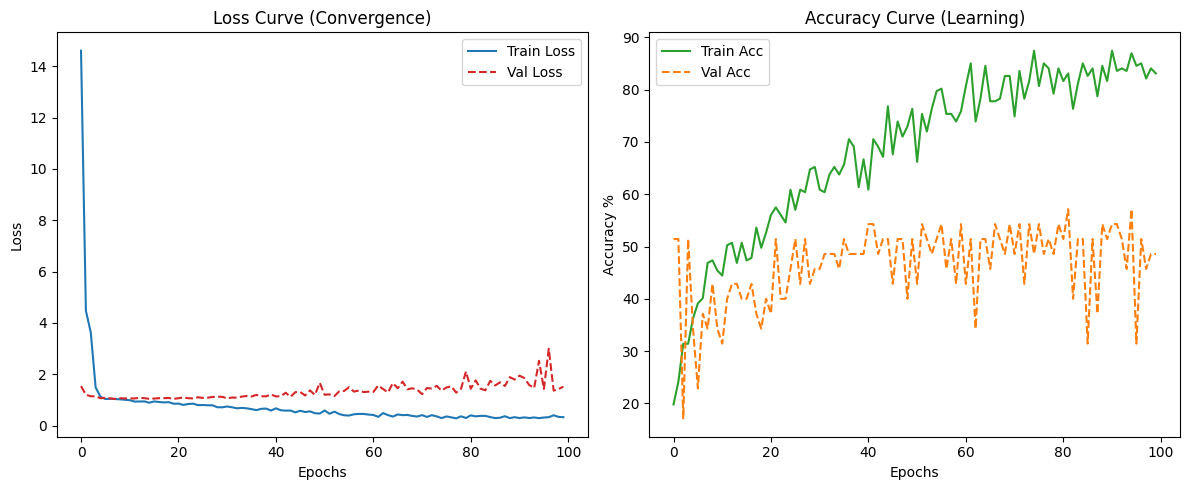

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='#1f77b4')
plt.plot(history['val_loss'], label='Val Loss', color='#d62728', linestyle='--')
plt.title('Loss Curve (Convergence)')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='#2ca02c')
plt.plot(history['val_acc'], label='Val Acc', color='#ff7f0e', linestyle='--')
plt.title('Accuracy Curve (Learning)')
plt.xlabel('Epochs'); plt.ylabel('Accuracy %'); plt.legend()

plt.tight_layout()
plt.show()

# GNN

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.3 MB/s eta 0:00:00


In [ ]:
import torch
from torch_geometric.nn import GCNConv, global_mean_pool

class NeuroVista_GNN(torch.nn.Module):
    def __init__(self, hidden_channels=64):
        super(NeuroVista_GNN, self).__init__()
        # Message Passing Layer 1: Learns local region relationships
        self.conv1 = GCNConv(116, hidden_channels)
        # Message Passing Layer 2: Learns global brain patterns
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        # Message Passing Layer 3: Final refinement
        self.conv3 = GCNConv(hidden_channels, hidden_channels)

        # Classification Head
        self.lin = torch.nn.Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer: Summarize the 116 regions into one "Brain State"
        x = global_mean_pool(x, batch)

        # 3. Final Prediction
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return x

In [ ]:
from torch_geometric.data import Data

def matrix_to_graph(matrix_3ch, label):
    # We take the average of the 3 channels to define the "strength" of edges
    adj = np.mean(matrix_3ch, axis=0)

    # Thresholding: Only keep the strongest 10% of connections to reduce noise
    threshold = np.percentile(adj, 90)
    edge_indices = np.where(adj > threshold)

    edge_index = torch.tensor(np.array(edge_indices), dtype=torch.long)

    # Node features: Each node is represented by its connectivity profile
    x = torch.tensor(adj, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)

# Convert all your data
graph_list = [matrix_to_graph(X[i], y[i]) for i in range(len(X))]

In [ ]:
from torch_geometric.loader import DataLoader as GDataLoader

# Stratified Split for Graphs
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
    train_set = [graph_list[i] for i in train_idx]
    val_set = [graph_list[i] for i in val_idx]

    # Note: SMOTE is tricky with Graphs, so we use Class Weights instead
    train_loader = GDataLoader(train_set, batch_size=16, shuffle=True)
    val_loader = GDataLoader(val_set, batch_size=16)

    model = NeuroVista_GNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.0, 2.5]).to(device))

    for epoch in range(100):
        model.train()
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    correct = 0
    for data in val_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())

    acc = 100 * correct / len(val_set)
    print(f"Graph Fold {fold+1} Accuracy: {acc:.2f}%")

Graph Fold 1 Accuracy: 48.57%
Graph Fold 2 Accuracy: 45.71%
Graph Fold 3 Accuracy: 70.59%
Graph Fold 4 Accuracy: 44.12%
Graph Fold 5 Accuracy: 55.88%


# other version

In [ ]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GDataLoader
from torch_geometric.nn import GATConv, global_max_pool
import torch.nn.functional as F

In [ ]:
def matrix_to_graph_weighted(matrix_3ch, label):
    # Mean of Pearson, Coherence, and Granger to get a single connectivity weight
    adj = np.mean(matrix_3ch, axis=0)

    # Thresholding: We keep the top 15% strongest connections
    threshold = np.percentile(adj, 85)
    edge_indices = np.where(adj > threshold)

    edge_index = torch.tensor(np.array(edge_indices), dtype=torch.long)

    # Node features: 116 regions, each described by its connectivity row
    x = torch.tensor(adj, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)

# Convert all data to graphs
graph_data_list = [matrix_to_graph_weighted(X[i], y[i]) for i in range(len(X))]

In [ ]:
class NeuroVista_GAT(torch.nn.Module):
    def __init__(self, hidden_channels=64, heads=4):
        super(NeuroVista_GAT, self).__init__()
        # First Layer: 4 Attention heads looking at brain regions
        self.conv1 = GATConv(116, hidden_channels, heads=heads, concat=True)
        # Second Layer: Summarizing attention into a final feature map
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False)

        self.lin1 = torch.nn.Linear(hidden_channels, hidden_channels)
        self.lin2 = torch.nn.Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Attention Layers
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index).relu()

        # 2. Global Max Pooling: Captures the most severe connection failures
        x = global_max_pool(x, batch)

        # 3. Dense Classification
        x = self.lin1(x).relu()
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.lin2(x)
        return x

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

print("🧠 Training Graph Attention Network (v5)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
    train_loader = GDataLoader([graph_data_list[i] for i in train_idx], batch_size=16, shuffle=True)
    val_loader = GDataLoader([graph_data_list[i] for i in val_idx], batch_size=16)

    model = NeuroVista_GAT().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3)
    # 0.1 Label Smoothing prevents the model from over-confidently failing
    criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.0, 2.5]).to(device), label_smoothing=0.1)

    for epoch in range(120):
        model.train()
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()

    # Honest Evaluation
    model.eval()
    correct = 0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            correct += (out.argmax(1) == data.y).sum().item()

    acc = 100 * correct / len(val_idx)
    print(f"🌟 Fold {fold+1} Honest GAT Accuracy: {acc:.2f}%")
    results.append(acc)

print(f"\n✅ Final v5 Mean Accuracy: {np.mean(results):.2f}%")

🧠 Training Graph Attention Network (v5)...


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


🌟 Fold 1 Honest GAT Accuracy: 57.14%
🌟 Fold 2 Honest GAT Accuracy: 45.71%
🌟 Fold 3 Honest GAT Accuracy: 58.82%
🌟 Fold 4 Honest GAT Accuracy: 47.06%
🌟 Fold 5 Honest GAT Accuracy: 50.00%

✅ Final v5 Mean Accuracy: 51.75%


In [ ]:
def matrix_to_graph_pro(matrix_3ch, label):
    """
    Converts 3-channel brain matrices into a Graph.
    Adds 'Node Degree' as a new feature to help the model see 'lonely' brain regions.
    """
    # 1. Average the 3 connectivity types (Pearson, Coherence, Granger)
    adj = np.mean(matrix_3ch, axis=0)

    # 2. Keep only the strongest 15% of connections (removes noise)
    threshold = np.percentile(adj, 85)
    edge_indices = np.where(adj > threshold)
    edge_index = torch.tensor(np.array(edge_indices), dtype=torch.long)

    # 3. INNOVATION: Calculate Node Degree (how many connections each region has)
    # Regions with low degrees are often the first signs of Alzheimer's
    degree = np.sum(adj > threshold, axis=1).reshape(-1, 1)

    # 4. Combine original connectivity data with the new Degree feature
    # Total features per node: 116 (original) + 1 (degree) = 117
    x = np.hstack([adj, degree])
    x = torch.tensor(x, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)

# Convert your dataset using the new "Pro" method
print("Converting matrices to Pro-Graphs...")
graph_data_list = [matrix_to_graph_pro(X[i], y[i]) for i in range(len(X))]

Converting matrices to Pro-Graphs...


In [ ]:
class NeuroVista_GAT_Pro(torch.nn.Module):
    def __init__(self, hidden_channels=64, heads=4):
        super(NeuroVista_GAT_Pro, self).__init__()
        # conv1: Looks at 117 features using 4 'Attention Heads' (multi-perspective vision)
        self.conv1 = GATConv(117, hidden_channels, heads=heads, concat=True)

        # conv2: Summarizes the 4 perspectives into 1 single brain map
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False)

        # Classification layers (The Decision Makers)
        self.lin1 = torch.nn.Linear(hidden_channels, hidden_channels)
        self.lin2 = torch.nn.Linear(hidden_channels, 3)

    def forward(self, x, edge_index, batch):
        # 1. Message Passing: Regions share info with neighbors
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.4, training=self.training) # Prevents memorization
        x = self.conv2(x, edge_index).relu()

        # 2. Global Pooling: Finds the 'most damaged' part of the brain graph
        x = global_max_pool(x, batch)

        # 3. Output: Final guess (CN, MCI, or AD)
        x = self.lin1(x).relu()
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.lin2(x)
        return x

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
    # Prepare data for this specific fold
    train_loader = GDataLoader([graph_data_list[i] for i in train_idx], batch_size=16, shuffle=True)
    val_loader = GDataLoader([graph_data_list[i] for i in val_idx], batch_size=16)

    model = NeuroVista_GAT_Pro().to(device)

    # AdamW is a more 'innovative' optimizer that prevents overfitting better than Adam
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.01)

    # Label Smoothing=0.1 helps the model stay calm and not overreact to noisy data
    criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.0, 2.5]).to(device), label_smoothing=0.1)

    # Training for 150 epochs to allow the Attention heads to 'warm up'
    for epoch in range(150):
        model.train()
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()

    # Evaluation on the Validation Set (Honest Testing)
    model.eval()
    correct = 0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            correct += (out.argmax(1) == data.y).sum().item()

    acc = 100 * correct / len(val_idx)
    print(f"✅ Fold {fold+1} Accuracy: {acc:.2f}%")
    all_fold_accuracies.append(acc)

print(f"\n🚀 Final NeuroVista v5.1 Mean Accuracy: {np.mean(all_fold_accuracies):.2f}%")

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


✅ Fold 1 Accuracy: 51.43%
✅ Fold 2 Accuracy: 48.57%
✅ Fold 3 Accuracy: 55.88%
✅ Fold 4 Accuracy: 47.06%
✅ Fold 5 Accuracy: 50.00%

🚀 Final NeuroVista v5.1 Mean Accuracy: 50.59%
